In [1]:
from pathlib import Path
import numpy as np 
import pandas as pd 
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import pickle
import altair as alt

### Load the file output by the process_icesat2.ipynb

In [2]:
atl06sr_gdf = pickle.load(open('../../data/icesat2/sierras_gdf_2018_2021_atl06_01312026_processed_masked.pkl', 'rb'))

In [3]:
sierras = gpd.read_file('../../data/misc/sierra_simplified.geojson')

In [5]:
atl06sr_gdf_cleaned = atl06sr_gdf.clip(sierras.to_crs(atl06sr_gdf.crs))

In [6]:
atl06sr_gdf_cleaned.shape

(5600953, 39)

In [7]:
atl06sr_gdf_cleaned[atl06sr_gdf_cleaned['reanalysis_sca']>0.9].shape

(942189, 39)

In [13]:
atl06sr_gdf_masked = atl06sr_gdf[atl06sr_gdf['mask']==1]

In [14]:
atl06sr_gdf_masked[atl06sr_gdf_masked['reanalysis_sca']>0.9].shape

(820003, 39)

In [15]:
atl06sr_gdf_cleaned[atl06sr_gdf_cleaned['reanalysis_sca']>0.9].shape

(942189, 39)

### calculate median snow depth:

In [36]:
# use open_mfdataset to open all years of swe/sca data at once, then open all sd data at once, and merge the two datasets saving the output file

base_dir = '../../swe_reanalysis_pca/data/download'

swe_sca_files = []
sd_files = []

for year in range(2019, 2022):
    year_folder = Path(base_dir) / str(year)
    swe_sca_files.append(f"{base_dir}/{year}/SWE_SCA_POST_{year}.nc")
    sd_files.append(f"{base_dir}/{year}/SD_POST_{year}.nc")

def preprocess_swe(ds):
    ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
    ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
    return ds

swe_sca_ds = xr.open_mfdataset(
    swe_sca_files,
    combine='by_coords',
    preprocess=preprocess_swe
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)


sd_ds = xr.open_mfdataset(
    sd_files,
    combine='by_coords'
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)

swe_sca_ds['SD_Post'] = sd_ds['SD_Post']


# swe_sca_ds = swe_sca_ds.rename({'Latitude': 'y', 'Longitude': 'x'})
# swe_sca_ds = swe_sca_ds.rio.set_spatial_dims('y', 'x', inplace=True)
swe_sca_ds['SWE_Post'] = swe_sca_ds['SWE_Post'].T
swe_sca_ds['SCA_Post'] = swe_sca_ds['SCA_Post'].T
swe_sca_ds = swe_sca_ds.transpose('time', 'y', 'x')
swe_sca_ds.rio.write_crs('EPSG:4326', inplace=True)
#swe_sca_ds['SD_Post'] = swe_sca_ds['SD_Post'].T

<xarray.Dataset> Size: 23GB
Dimensions:      (time: 1096, y: 1575, x: 1125)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 9kB 2018-10-01 2018-10-02 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

In [30]:
# use open_mfdataset to open all years of swe/sca data at once, then open all sd data at once, and merge the two datasets saving the output file

base_dir = '../../swe_reanalysis_pca/data/download'

swe_sca_files = []
sd_files = []

for year in range(1985, 2022):
    year_folder = Path(base_dir) / str(year)
    swe_sca_files.append(f"{base_dir}/{year}/SWE_SCA_POST_{year}.nc")
    sd_files.append(f"{base_dir}/{year}/SD_POST_{year}.nc")

def preprocess_swe(ds):
    ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
    ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
    return ds

swe_sca_ds_allyrs = xr.open_mfdataset(
    swe_sca_files,
    combine='by_coords',
    preprocess=preprocess_swe
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)


sd_ds_allyrs = xr.open_mfdataset(
    sd_files,
    combine='by_coords'
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)

swe_sca_ds_allyrs['SD_Post'] = sd_ds_allyrs['SD_Post']


# swe_sca_ds = swe_sca_ds.rename({'Latitude': 'y', 'Longitude': 'x'})
# swe_sca_ds = swe_sca_ds.rio.set_spatial_dims('y', 'x', inplace=True)
swe_sca_ds_allyrs['SWE_Post'] = swe_sca_ds_allyrs['SWE_Post'].T
swe_sca_ds_allyrs['SCA_Post'] = swe_sca_ds_allyrs['SCA_Post'].T
swe_sca_ds_allyrs = swe_sca_ds_allyrs.transpose('time', 'y', 'x')
swe_sca_ds_allyrs.rio.write_crs('EPSG:4326', inplace=True)
#swe_sca_ds['SD_Post'] = swe_sca_ds['SD_Post'].T

<xarray.Dataset> Size: 287GB
Dimensions:      (time: 13514, y: 1575, x: 1125)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 108kB 1984-10-01 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

In [33]:
# 1. Select April 1 of each year
swe_sca_ds_allyrs_april1 = swe_sca_ds_allyrs.sel(time=( (swe_sca_ds_allyrs['time'].dt.month == 4) & (swe_sca_ds_allyrs['time'].dt.day == 1) ))

In [34]:
# 2. Compute mean April 1 snow depth across years
swe_sca_ds_allyrs_april1 = swe_sca_ds_allyrs_april1.mean(dim='time', skipna=True)

In [35]:
# 3. Threshold mask
mask = swe_sca_ds_allyrs_april1.SCA_Post > 0.5

### Get timeseries of median/average reanalysis snow depth:

In [37]:
swe_sca_ds = swe_sca_ds.rename({'y': 'lat', 'x': 'lon'})

In [32]:
swe_sca_ds_allyrs = swe_sca_ds_allyrs.rename({'y': 'lat', 'x': 'lon'})

In [38]:
# 4. Apply mask
swe_sca_ds_roi = swe_sca_ds.where(mask)

In [39]:
# 5. Compute spatial median
median_sd = swe_sca_ds_roi.median(dim=('lat', 'lon'), skipna=True).compute()

### Things I want to test:  
* just subset based on 1 april fsca > 0.5 (mask). 
* subset on 1 april fsca > 0.5 (mask) and fsca > 0.9 
* subset on fsca > 0.9 
* different combinations of slope, dh_fit_dx, h_sigma, rms_misfit, and per day sample size

In [16]:
atl06sr_gdf_cleaned.columns.tolist()

['pflags',
 'x_atc',
 'h_mean',
 'gt',
 'dh_fit_dx',
 'n_fit_photons',
 'spot',
 'region',
 'cycle',
 'h_sigma',
 'w_surface_window_final',
 'rgt',
 'segment_id',
 'y_atc',
 'rms_misfit',
 'geometry',
 'segment_snowcover',
 'segment_landcover',
 'beam_azimuth',
 'segment_watermask',
 'urban_flag',
 '3dep.aspect',
 '3dep.flags',
 '3dep.time',
 '3dep.count',
 '3dep.value',
 '3dep.slope',
 '3dep.file_id',
 'water_year',
 'doy',
 'decyear',
 'dowy',
 'acqdate',
 'acqdate_dt',
 'reanalysis_swe',
 'reanalysis_sca',
 'reanalysis_sd',
 'icesat2_3dep_dif',
 'mask']

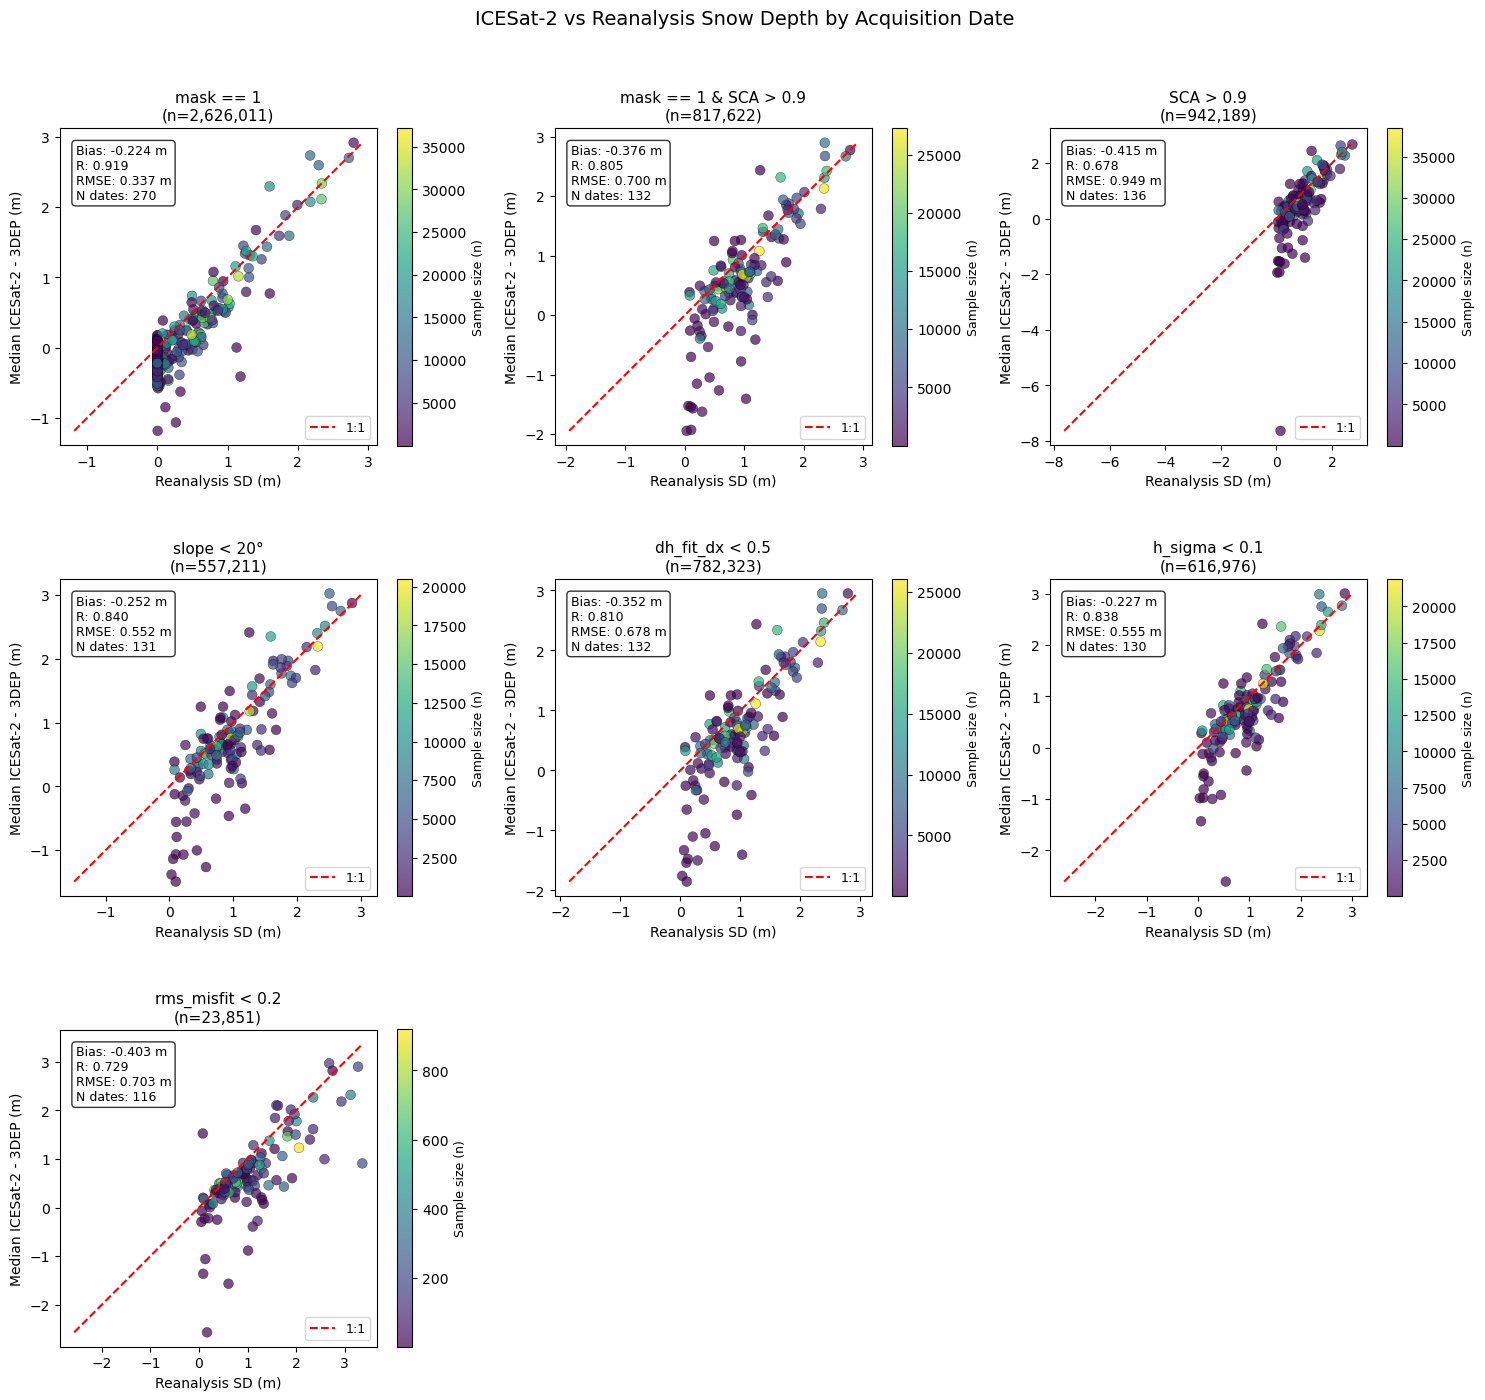

In [18]:
from scipy import stats

def compute_metrics(x, y):
    """Compute bias, correlation, RMSE between x and y"""
    valid = ~(np.isnan(x) | np.isnan(y))
    x_valid, y_valid = x[valid], y[valid]
    if len(x_valid) < 2:
        return np.nan, np.nan, np.nan, 0
    bias = np.mean(y_valid - x_valid)
    rmse = np.sqrt(np.mean((y_valid - x_valid)**2))
    r, _ = stats.pearsonr(x_valid, y_valid)
    return bias, r, rmse, len(x_valid)

def scatter_with_metrics(ax, df, x_col, y_col, group_col, title, cmap='viridis'):
    """Create scatter plot of median values grouped by acqdate, colored by sample size"""
    # Group by acquisition date and compute median and count
    grouped = df.groupby(group_col).agg({
        x_col: 'median',
        y_col: 'median',
        'geometry': 'count'  # count for sample size
    }).rename(columns={'geometry': 'n'}).dropna()
    
    if len(grouped) < 2:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        return
    
    # Compute metrics
    bias, r, rmse, n_total = compute_metrics(grouped[x_col].values, grouped[y_col].values)
    
    # Create scatter plot
    sc = ax.scatter(grouped[x_col], grouped[y_col], c=grouped['n'], 
                    cmap=cmap, alpha=0.7, edgecolor='k', linewidth=0.3, s=50)
    
    # Add 1:1 line
    lims = [min(grouped[x_col].min(), grouped[y_col].min()),
            max(grouped[x_col].max(), grouped[y_col].max())]
    ax.plot(lims, lims, 'r--', lw=1.5, label='1:1')
    
    # Add colorbar
    cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
    cbar.set_label('Sample size (n)', fontsize=9)
    
    # Add metrics text
    metrics_text = f'Bias: {bias:.3f} m\nR: {r:.3f}\nRMSE: {rmse:.3f} m\nN dates: {len(grouped)}'
    ax.text(0.05, 0.95, metrics_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel('Reanalysis SD (m)', fontsize=10)
    ax.set_ylabel('Median ICESat-2 - 3DEP (m)', fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.legend(loc='lower right', fontsize=9)
    ax.set_aspect('equal', adjustable='box')

# Define the subsets to test
# Base subset for quality metrics (mask==1 and SCA>0.9)
base_subset = atl06sr_gdf_cleaned[(atl06sr_gdf_cleaned['mask'] == 1) & (atl06sr_gdf_cleaned['reanalysis_sca'] > 0.9)]

subsets = {
    'mask == 1': atl06sr_gdf_cleaned[atl06sr_gdf_cleaned['mask'] == 1],
    'mask == 1 & SCA > 0.9': base_subset,
    'SCA > 0.9': atl06sr_gdf_cleaned[atl06sr_gdf_cleaned['reanalysis_sca'] > 0.9],
    'slope < 20°': base_subset[base_subset['3dep.slope'] < 20],
    'dh_fit_dx < 0.5': base_subset[base_subset['dh_fit_dx'].abs() < 0.5],
    'h_sigma < 0.1': base_subset[base_subset['h_sigma'] < 0.1],
    'rms_misfit < 0.2': base_subset[base_subset['rms_misfit'] < 0.2],
}

# Create figure with subplots
fig, axes = plt.subplots(3, 3, figsize=(15, 14))
axes = axes.flatten()

for idx, (name, subset_df) in enumerate(subsets.items()):
    scatter_with_metrics(axes[idx], subset_df, 'reanalysis_sd', 'icesat2_3dep_dif', 
                         'acqdate', f'{name}\n(n={len(subset_df):,})')

# Hide extra subplots
for idx in range(len(subsets), len(axes)):
    axes[idx].axis('off')

plt.suptitle('ICESat-2 vs Reanalysis Snow Depth by Acquisition Date', fontsize=14, y=1.01)
plt.tight_layout()
#plt.savefig('../../figures/for_paper/scatter_subsets_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

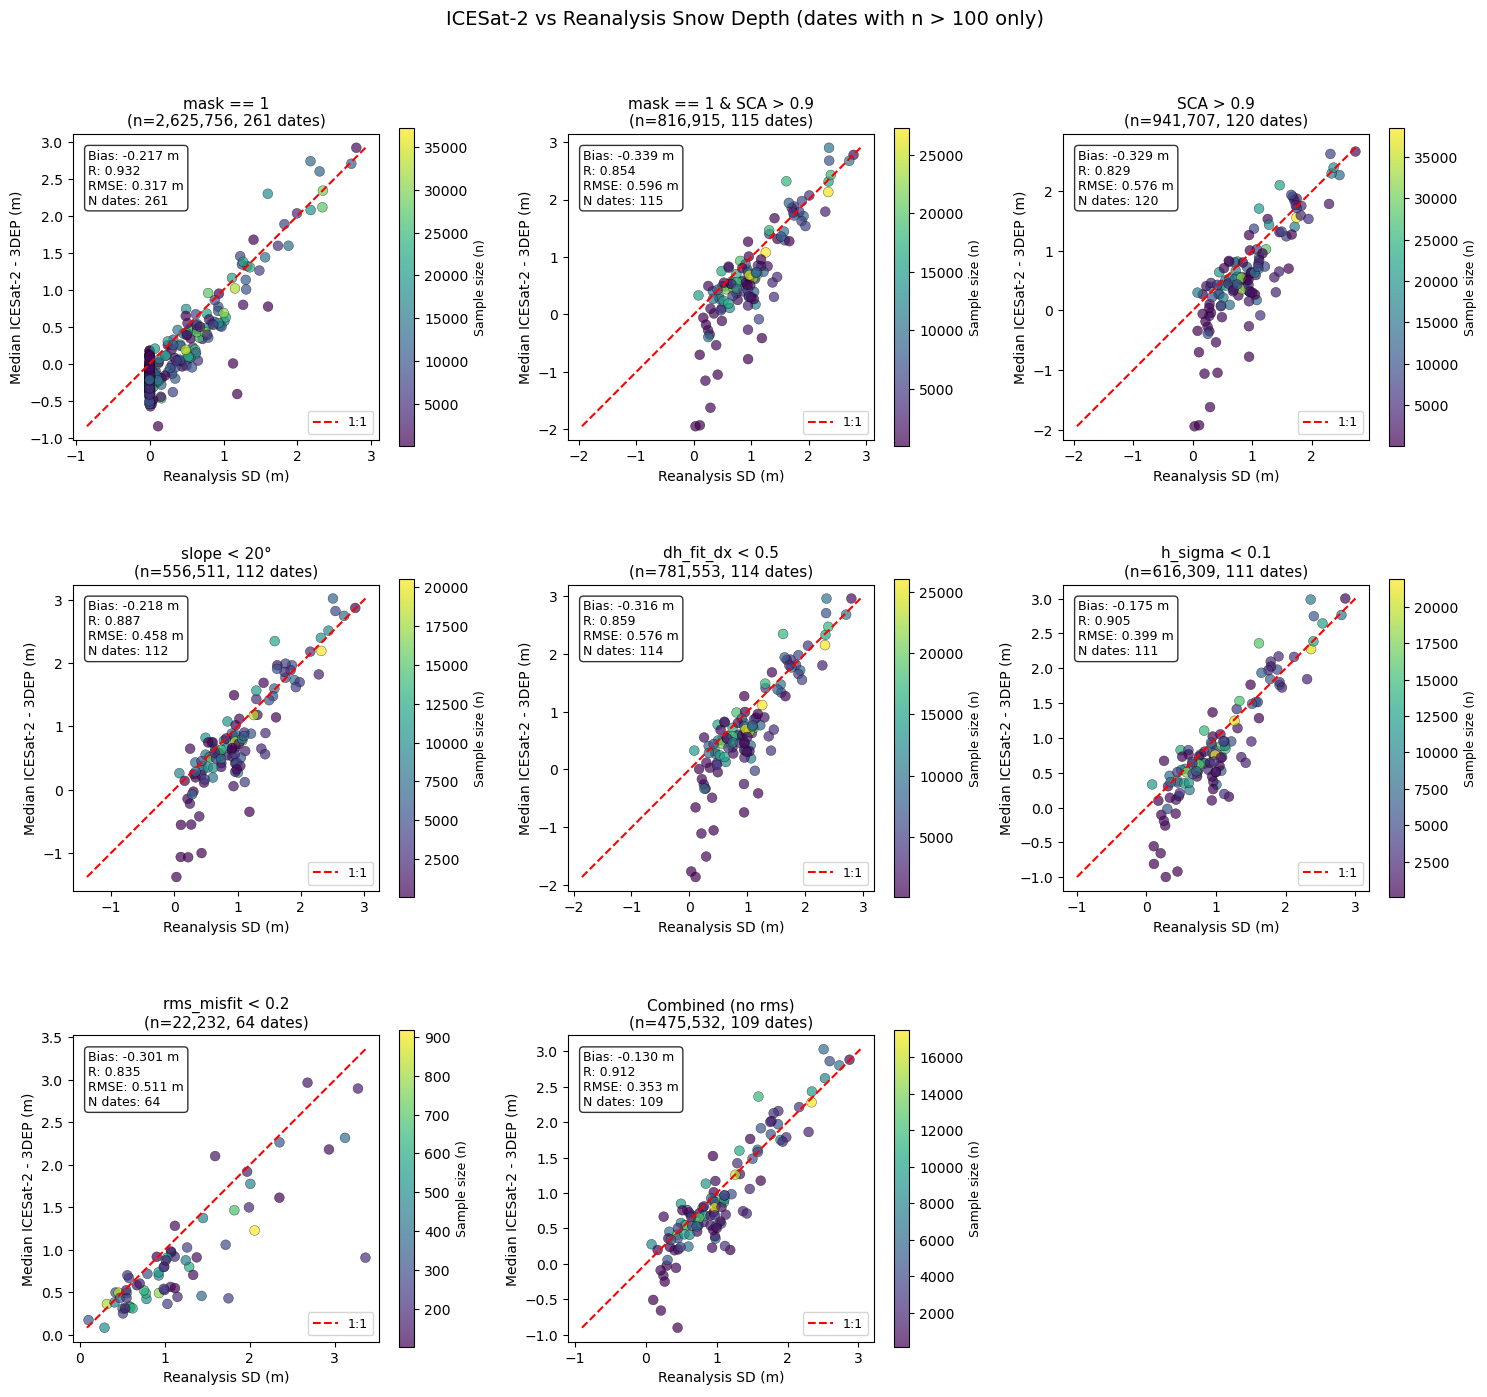

In [21]:
# Repeat analysis but only include dates with sample size > 100

def filter_by_min_sample_size(df, group_col='acqdate', min_n=100):
    """Filter dataframe to only include groups with at least min_n samples"""
    counts = df.groupby(group_col).size()
    valid_dates = counts[counts >= min_n].index
    return df[df[group_col].isin(valid_dates)]

# Define subsets with sample size filter
base_subset_n100 = filter_by_min_sample_size(base_subset, min_n=100)

# Combined subset: all filters except rms_misfit
combined_subset = atl06sr_gdf_cleaned[
    (atl06sr_gdf_cleaned['mask'] == 1) & 
    (atl06sr_gdf_cleaned['reanalysis_sca'] > 0.9) &
    (atl06sr_gdf_cleaned['3dep.slope'] < 20) &
    (atl06sr_gdf_cleaned['dh_fit_dx'].abs() < 0.5) &
    (atl06sr_gdf_cleaned['h_sigma'] < 0.1)
]
combined_subset_n100 = filter_by_min_sample_size(combined_subset, min_n=100)

subsets_n100 = {
    'mask == 1': filter_by_min_sample_size(atl06sr_gdf_cleaned[atl06sr_gdf_cleaned['mask'] == 1], min_n=100),
    'mask == 1 & SCA > 0.9': base_subset_n100,
    'SCA > 0.9': filter_by_min_sample_size(atl06sr_gdf_cleaned[atl06sr_gdf_cleaned['reanalysis_sca'] > 0.9], min_n=100),
    'slope < 20°': filter_by_min_sample_size(base_subset[base_subset['3dep.slope'] < 20], min_n=100),
    'dh_fit_dx < 0.5': filter_by_min_sample_size(base_subset[base_subset['dh_fit_dx'].abs() < 0.5], min_n=100),
    'h_sigma < 0.1': filter_by_min_sample_size(base_subset[base_subset['h_sigma'] < 0.1], min_n=100),
    'rms_misfit < 0.2': filter_by_min_sample_size(base_subset[base_subset['rms_misfit'] < 0.2], min_n=100),
    'Combined (no rms)': combined_subset_n100,
}

# Create figure with subplots
fig, axes = plt.subplots(3, 3, figsize=(15, 14))
axes = axes.flatten()

for idx, (name, subset_df) in enumerate(subsets_n100.items()):
    n_dates = subset_df.groupby('acqdate').ngroups
    scatter_with_metrics(axes[idx], subset_df, 'reanalysis_sd', 'icesat2_3dep_dif', 
                         'acqdate', f'{name}\n(n={len(subset_df):,}, {n_dates} dates)')

# Hide extra subplots
for idx in range(len(subsets_n100), len(axes)):
    axes[idx].axis('off')

plt.suptitle('ICESat-2 vs Reanalysis Snow Depth (dates with n > 100 only)', fontsize=14, y=1.01)
plt.tight_layout()
#plt.savefig('../../figures/for_paper/scatter_subsets_comparison_n100.png', dpi=300, bbox_inches='tight')
plt.show()

Combined subset: 475,532 points, 109 dates


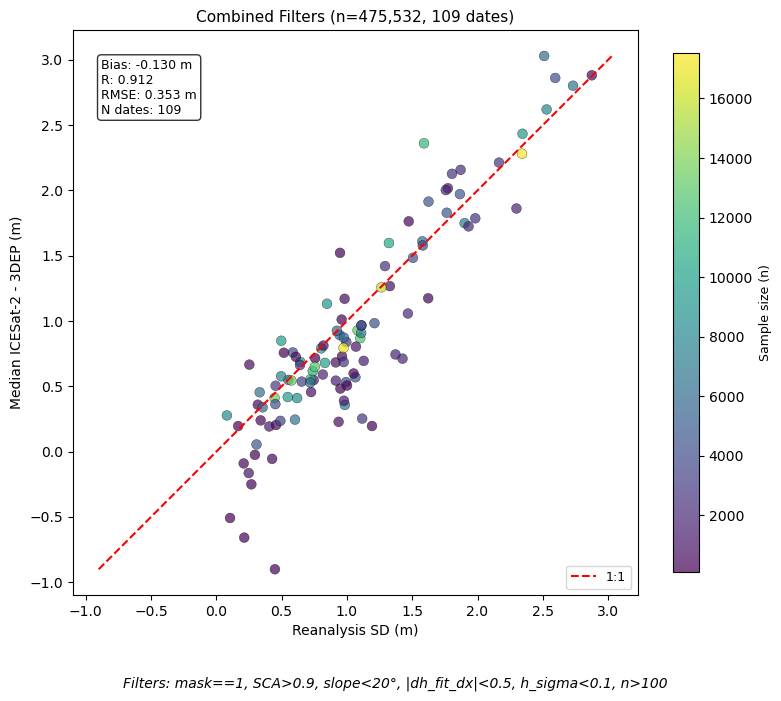

In [20]:
# Combined subset: all filters except rms_misfit
# mask==1, SCA>0.9, slope<20, dh_fit_dx<0.5, h_sigma<0.1, sample size>100

combined_subset = atl06sr_gdf_cleaned[
    (atl06sr_gdf_cleaned['mask'] == 1) & 
    (atl06sr_gdf_cleaned['reanalysis_sca'] > 0.9) &
    (atl06sr_gdf_cleaned['3dep.slope'] < 20) &
    (atl06sr_gdf_cleaned['dh_fit_dx'].abs() < 0.5) &
    (atl06sr_gdf_cleaned['h_sigma'] < 0.1)
]

# Apply sample size filter
combined_subset_n100 = filter_by_min_sample_size(combined_subset, min_n=100)

n_dates = combined_subset_n100.groupby('acqdate').ngroups
print(f"Combined subset: {len(combined_subset_n100):,} points, {n_dates} dates")

# Create single scatter plot
fig, ax = plt.subplots(figsize=(8, 7))

scatter_with_metrics(ax, combined_subset_n100, 'reanalysis_sd', 'icesat2_3dep_dif', 
                     'acqdate', f'Combined Filters (n={len(combined_subset_n100):,}, {n_dates} dates)')

# Add subtitle with filter details
fig.text(0.5, -0.02, 'Filters: mask==1, SCA>0.9, slope<20°, |dh_fit_dx|<0.5, h_sigma<0.1, n>100', 
         ha='center', fontsize=10, style='italic')

plt.tight_layout()
#plt.savefig('../../figures/for_paper/scatter_combined_filters.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
import matplotlib.dates as mdates
import matplotlib.cbook as cbook
from matplotlib.ticker import FuncFormatter

In [23]:
mpl_epoch = '1970-01-01'

In [24]:
highlight_dates = ['2019-03-16','2020-04-11','2021-04-01']
# highlight_dates = ['2019-04-11 00:00:00']
highlight_dates_dt = pd.to_datetime(highlight_dates)

In [41]:
# Repeat analysis but only include dates with sample size > 100

def filter_by_min_sample_size(df, group_col='acqdate', min_n=100):
    """Filter dataframe to only include groups with at least min_n samples"""
    counts = df.groupby(group_col).size()
    valid_dates = counts[counts >= min_n].index
    return df[df[group_col].isin(valid_dates)]

# Define subsets with sample size filter
base_subset_n100 = filter_by_min_sample_size(base_subset, min_n=100)

# Combined subset: all filters except rms_misfit
combined_subset2 = atl06sr_gdf_cleaned[
    (atl06sr_gdf_cleaned['mask'] == 1) & 
    #(atl06sr_gdf_cleaned['reanalysis_sca'] > 0.9) &
    (atl06sr_gdf_cleaned['3dep.slope'] < 20) &
    (atl06sr_gdf_cleaned['dh_fit_dx'].abs() < 0.5) &
    (atl06sr_gdf_cleaned['h_sigma'] < 0.1)
]
combined_subset_n100_2 = filter_by_min_sample_size(combined_subset2, min_n=100)

In [25]:
# Function adapted from David Shean by Hannah Besso
# Allows for multiple levels of data to be plotted. Can just plot in situ snow depth, or can add any/all of the following:
# ICESat-2, sampled ASO, and full-site ASO

def boxplot_timeseries_highlights(df=None, col=None, groupby_col='acqdate', highlights=None,
                         title='Sierras Median Snow Depth', name='../figures/boxplots_cdec_aso.jpeg', 
                         main_color=None, highlight_color=None, clim=(-2, 5)):
    
    df_nh = df[~df['acqdate_dt'].isin(highlights)]
    df_h = df[df['acqdate_dt'].isin(highlights)]

    # ATL06 stats
    if df is not None:
        bp_stats_nh = df_nh[[col, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
        bp_stats_list_nh = [i[0] for i in bp_stats_nh.values]
        bp_alpha_nh = df_nh[[col, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
        bp_alpha_boxes_nh = bp_alpha_nh/bp_alpha_nh.max()
        pos_nh = (pd.to_datetime(bp_stats_nh.index) - pd.to_datetime(mpl_epoch)).days.values

    if highlights is not None:
        bp_stats_h = df_h[[col, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
        bp_stats_list_h = [i[0] for i in bp_stats_h.values]
        bp_alpha_h = df_h[[col, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
        bp_alpha_boxes_h = bp_alpha_h/bp_alpha_h.max()
        pos_h = (pd.to_datetime(bp_stats_h.index) - pd.to_datetime(mpl_epoch)).days.values
    
    f, ax = plt.subplots(figsize=(15,7))
    
    median_sd.SD_Post.plot(label='Spatial Median (Apr 1 Mean fSCA > 0.5 mm)', color='k', linewidth=1)
    
    # Plot ATL06 data
    if df is not None:
        bxp_f_nh = ax.bxp(bp_stats_list_nh, positions=pos_nh, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.3, 'facecolor':main_color},  
                   medianprops={'lw':3, 'color':main_color},widths=10, patch_artist=True, zorder=1)
        for patch, alpha in zip(bxp_f_nh['boxes'], bp_alpha_boxes_nh):
            patch.set_edgecolor('None')
            patch.set_linewidth(0)

       # Plot highlight data
    if highlights is not None:
        bxp_f_h = ax.bxp(bp_stats_list_h, positions=pos_h, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.5, 'facecolor':highlight_color},  
                   medianprops={'lw':3, 'color':highlight_color},widths=10, patch_artist=True, zorder=2)
        for patch, alpha in zip(bxp_f_h['boxes'], bp_alpha_boxes_h):
            patch.set_edgecolor('None')
            patch.set_linewidth(0)

    ax.set_title(title, fontsize=24)
    
    
    #set the ATL06SR alpha (transparency) for each box, whisker, and median according to the number of samples for that measurement
    # if df is not None:
    #     for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    #         patch.set_edgecolor('None')
    #         patch.set_linewidth(0)
    # if df is not None:
    #     for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    #         patch.set_color('k')  # or deeppink  
    
    ax.axhline(0, color='k', lw=0.5)
    ax.set_ylabel('Snow Depth (m)', fontsize=22)
    ax.set_ylim(*clim)
    ax.set_xlim([dt_min_plot, dt_max_plot])
    
    
    # X AXIS LABELS     
    months = mdates.MonthLocator()
    month_fmt = mdates.DateFormatter('%b')
    
    def m_fmt(x, pos=None):
        return month_fmt(x)[0]
    
    ax.xaxis.set_minor_locator(months) 
    ax.xaxis.set_minor_formatter(FuncFormatter(m_fmt))
    
    years = mdates.MonthLocator(bymonth=1)
    ax.format_xdata = mdates.DateFormatter('%Y')
    years_fmt = mdates.DateFormatter('%Y')
    ax.xaxis.set_major_locator(years)
    ax.xaxis.set_major_formatter(years_fmt)
    ax.tick_params('both', length=5, width=1.5, which='major')
    ax.tick_params('both', length=5, width=1.5, which='minor')
    
    #ax.legend(custom, custom_labels, loc='upper right', prop={'size':18}, fancybox=True, framealpha=0.5) #, fontsize=10
    
    for label in ax.get_xticklabels(which='major'): #
        label.set(rotation=90, horizontalalignment='center')
    
    plt.tight_layout()
    #plt.savefig(f'{name}', dpi=500)

In [26]:
import datetime
from matplotlib.lines import Line2D
#from datetime import datetime

In [27]:
icesat2_color = '#69BC6B'
icesat2_median_color = '#64A366' # '#6BB567' 
reanalysis_color = '#1C6BAB'
highlight_color2 = '#750075' # purple
#highlight_color = '#FF9D98' # coral
#highlight_color = '#FD8D3C' # orange
highlight_color = '#E6550D' # reddish orange

In [28]:
combined_subset_n100

,pflags,x_atc,h_mean,gt,dh_fit_dx,n_fit_photons,spot,region,cycle,h_sigma,...,doy,decyear,dowy,acqdate,acqdate_dt,reanalysis_swe,reanalysis_sca,reanalysis_sd,icesat2_3dep_dif,mask
time,,,,,,,,,,,,,,,,,,,,,
2019-01-10 19:09:58.585844480,0,3980463.0,2433.143063,50,-0.122606,63,5,region_1_south,2,0.068107,...,10,2019.026845,102,2019-01-10,2019-01-10,0.117664,0.995396,0.507508,2.285600,1
2020-01-09 01:49:07.577709824,0,3980483.0,2411.958489,10,0.085581,44,6,region_1_south,6,0.064521,...,9,2020.022065,101,2020-01-09,2020-01-09,0.168144,0.966472,0.502143,0.752823,1
2020-01-09 01:49:07.580524544,0,3980503.0,2413.053276,10,0.018764,70,6,region_1_south,6,0.023923,...,9,2020.022065,101,2020-01-09,2020-01-09,0.171422,0.968943,0.511851,0.344071,1
2020-01-09 01:49:07.583339264,0,3980523.0,2412.910966,10,-0.034177,60,6,region_1_south,6,0.051694,...,9,2020.022065,101,2020-01-09,2020-01-09,0.174711,0.971478,0.521595,0.142312,1
2020-01-09 01:49:07.586152704,0,3980543.0,2410.610653,10,-0.156617,26,6,region_1_south,6,0.076251,...,9,2020.022065,101,2020-01-09,2020-01-09,0.178010,0.974073,0.531368,-0.840010,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-04-15 09:30:49.871121408,0,15585094.0,1987.804862,50,0.289634,21,2,region_4_north,7,0.090330,...,106,2020.287968,198,2020-04-15,2020-04-15,0.208366,0.931640,0.565077,-0.404644,1
2020-01-15 13:51:02.303883520,0,15585094.0,1990.528818,60,0.214147,43,1,region_4_north,6,0.089773,...,15,2020.039828,107,2020-01-15,2020-01-15,0.167188,0.996490,0.658936,-2.088312,1
2019-04-18 02:51:44.669886976,0,15585094.0,1990.753528,60,0.239286,37,6,region_4_north,3,0.081233,...,108,2019.293477,200,2019-04-18,2019-04-18,0.441952,0.986415,1.018791,2.536641,1


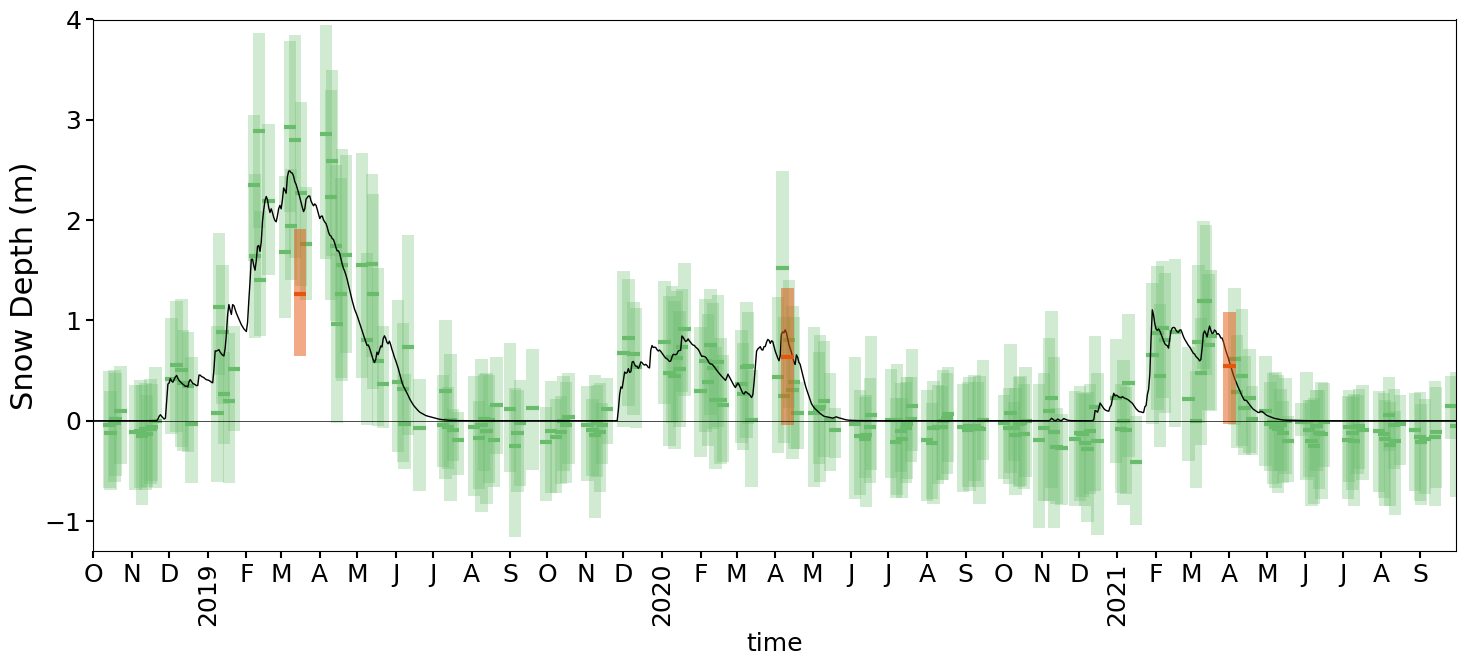

In [42]:
plt.rcParams['font.size'] = '18'
dt_min_plot = datetime.date(2018, 10, 1)
dt_max_plot = datetime.date(2021, 9, 30)

boxplot_timeseries_highlights(df=combined_subset_n100_2, col='icesat2_3dep_dif', groupby_col='acqdate', highlights=highlight_dates_dt,
                         title='', name='../../figures/boxplots_icesat2_highlights.png', 
                         main_color=icesat2_color, highlight_color=highlight_color, clim=(-1.3, 4))

In [44]:
# Repeat analysis but only include dates with sample size > 100

def filter_by_min_sample_size(df, group_col='acqdate', min_n=100):
    """Filter dataframe to only include groups with at least min_n samples"""
    counts = df.groupby(group_col).size()
    valid_dates = counts[counts >= min_n].index
    return df[df[group_col].isin(valid_dates)]

# Define subsets with sample size filter
base_subset_n100 = filter_by_min_sample_size(base_subset, min_n=100)

# Combined subset: all filters except rms_misfit
combined_subset3 = atl06sr_gdf_cleaned[
    (atl06sr_gdf_cleaned['mask'] == 1) & 
    #(atl06sr_gdf_cleaned['reanalysis_sca'] > 0.9) &
    (atl06sr_gdf_cleaned['3dep.slope'] < 20) #&
    #(atl06sr_gdf_cleaned['dh_fit_dx'].abs() < 0.5) &
    #(atl06sr_gdf_cleaned['h_sigma'] < 0.1)
]
combined_subset_n100_3 = filter_by_min_sample_size(combined_subset3, min_n=100)

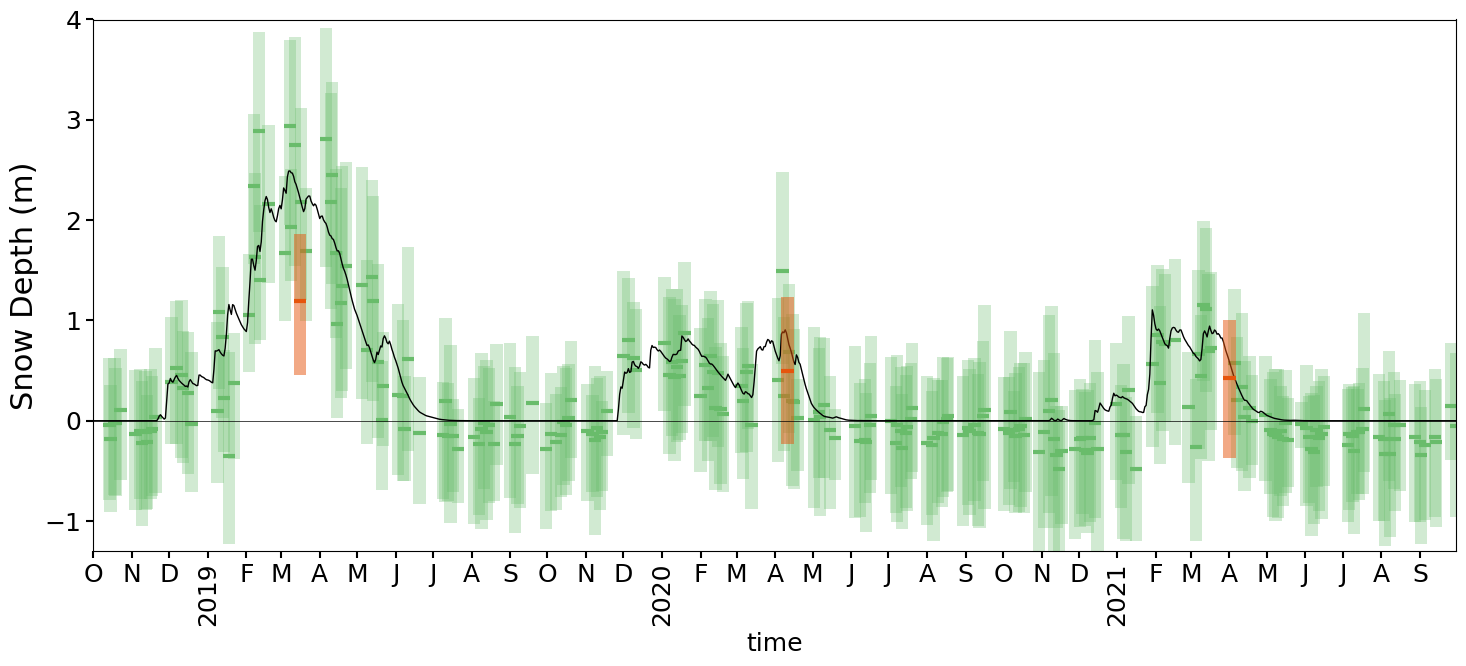

In [45]:
plt.rcParams['font.size'] = '18'
dt_min_plot = datetime.date(2018, 10, 1)
dt_max_plot = datetime.date(2021, 9, 30)

boxplot_timeseries_highlights(df=combined_subset_n100_3, col='icesat2_3dep_dif', groupby_col='acqdate', highlights=highlight_dates_dt,
                         title='', name='../../figures/boxplots_icesat2_highlights.png', 
                         main_color=icesat2_color, highlight_color=highlight_color, clim=(-1.3, 4))

/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_6740/552241593.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 0.96])


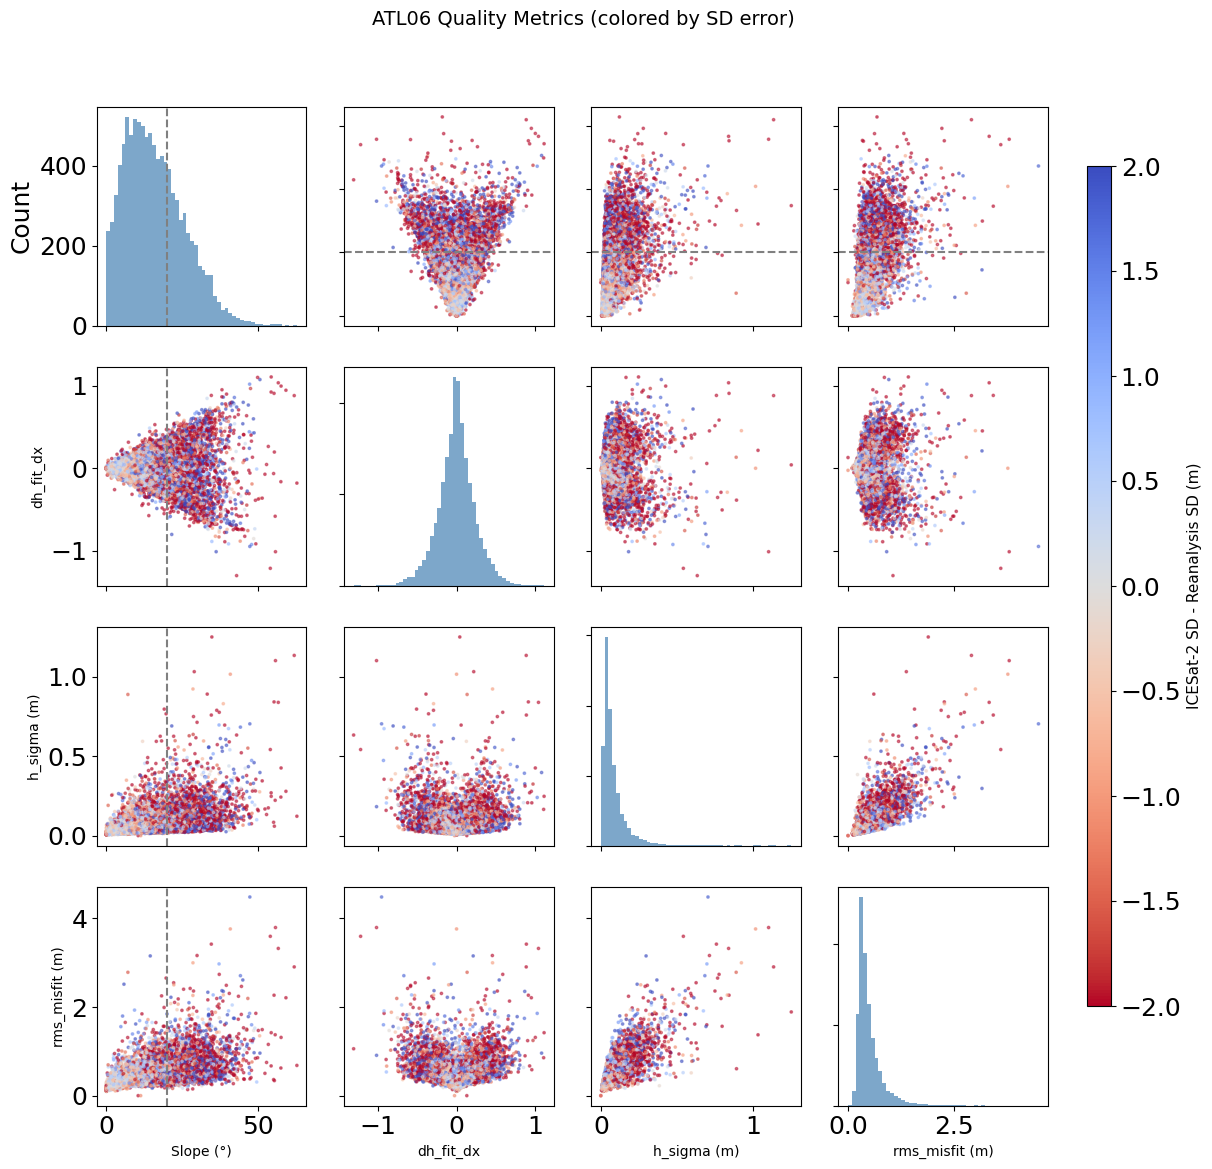

In [48]:
# Multi-dimensional scatter plot showing slope, dh_fit_dx, h_sigma, and rms_misfit
# Using a scatter matrix (pairplot) with color encoding for icesat2_3dep_dif

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# Sample subset for visualization (too many points will be slow)
sample_size = 10000
plot_df = base_subset.sample(n=min(sample_size, len(base_subset)), random_state=42).copy()

# Columns to visualize
cols = ['3dep.slope', 'dh_fit_dx', 'h_sigma', 'rms_misfit']
labels = ['Slope (°)', 'dh_fit_dx', 'h_sigma (m)', 'rms_misfit (m)']

# Color by difference between icesat2_3dep_dif and reanalysis_sd
plot_df['sd_error'] = plot_df['icesat2_3dep_dif'] - plot_df['reanalysis_sd']
vmin, vmax = -2, 2
norm = Normalize(vmin=vmin, vmax=vmax)
colors = plt.cm.coolwarm_r(norm(plot_df['sd_error'].clip(vmin, vmax)))

# Create scatter matrix
n = len(cols)
fig, axes = plt.subplots(n, n, figsize=(12, 12))

for i, (col_y, label_y) in enumerate(zip(cols, labels)):
    for j, (col_x, label_x) in enumerate(zip(cols, labels)):
        ax = axes[i, j]
        
        if i == j:
            # Diagonal: histogram
            ax.hist(plot_df[col_y].dropna(), bins=50, color='steelblue', alpha=0.7, edgecolor='none')
            ax.set_ylabel('Count' if j == 0 else '')
            # Add vertical line at slope=20 on slope histogram
            if col_y == '3dep.slope':
                ax.axvline(x=20, color='grey', linestyle='--', linewidth=1.5)
        else:
            # Off-diagonal: scatter plot
            ax.scatter(plot_df[col_x], plot_df[col_y], c=colors, s=3, alpha=0.5, rasterized=True)
            # Add reference lines at slope=20
            if col_x == '3dep.slope':
                ax.axvline(x=20, color='grey', linestyle='--', linewidth=1.5)
            if col_y == '3dep.slope':
                ax.axhline(y=20, color='grey', linestyle='--', linewidth=1.5)
        
        # Labels
        if i == n - 1:
            ax.set_xlabel(label_x, fontsize=10)
        if j == 0 and i != j:
            ax.set_ylabel(label_y, fontsize=10)
        
        # Remove tick labels for inner plots
        if i < n - 1:
            ax.set_xticklabels([])
        if j > 0:
            ax.set_yticklabels([])

# Add colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
sm = ScalarMappable(norm=norm, cmap='coolwarm_r')
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('ICESat-2 SD - Reanalysis SD (m)', fontsize=11)

plt.suptitle('ATL06 Quality Metrics (colored by SD error)', fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0, 0.91, 0.96])
plt.show()